# 02 — LLM Emotional Intelligence Benchmark

Evaluates LLM emotional intelligence for urban agent simulation using two complementary tests:

### Part A — EQ-Bench v2 (Paech, 2024) — Standard Benchmark
171 dialogue-based questions testing emotional intensity prediction on a 0–10 scale.
Scores calibrated so 0 = random, 100 = perfect match with reference answers.
Results comparable to the [public leaderboard](https://eqbench.com).

### Part B — Urban Emotion Test (supplementary) — Domain-Specific
15 urban scenarios scored with Plutchik (1980) + NRC lexicon methodology (Mohammad & Turney, 2013).

**Providers tested:**
- **Ollama + Llama 3.1** (local)
- **Ollama + Qwen 2.5-Coder 3B** (local)
- **DeepSeek V4 Fast** (cloud API)

In [21]:
import asyncio
import json
import time
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from openai import AsyncOpenAI

sns.set_theme(style="whitegrid", palette="muted")

with open("data/emotion_scenarios.json") as f:
    SCENARIOS = json.load(f)

print(f"Loaded {len(SCENARIOS)} emotion scenarios across categories: "
      f"{sorted(set(s['category'] for s in SCENARIOS))}")

PROVIDERS = {
    "llama3.1": {
        "base_url": "http://localhost:11434/v1",
        "api_key":  "ollama",
        "model":    "llama3.1:latest",
        "label":    "Ollama Llama 3.1",
    },
    "qwen2.5-coder": {
        "base_url": "http://localhost:11434/v1",
        "api_key":  "ollama",
        "model":    "qwen2.5-coder:3b",
        "label":    "Ollama Qwen 2.5-Coder 3B",
    },
    "deepseek": {
        "base_url": "https://api.deepseek.com/v1",
        "api_key":  os.getenv("DEEPSEEK_API_KEY", "sk-9b7ab00231064718aeba52367bbeb826"),
        "model":    os.getenv("DEEPSEEK_MODEL", "deepseek-chat"),
        "label":    "DeepSeek V4 Fast",
    },
}

Loaded 15 emotion scenarios across categories: ['empathy', 'escalation', 'negative_shift', 'nuanced', 'positive_shift']


## Part A — EQ-Bench v2 (Paech, 2024)

Standard benchmark for LLM emotional intelligence. Each question presents a dialogue
and asks the model to rate 4 emotions on a 0–10 intensity scale. Scores are compared
against expert reference answers using a sigmoid-weighted distance formula.

**Scoring (Paech, 2024):** For each emotion, difference `d` from reference is scaled:
- `d ≤ 5`: `6.5 × σ(−1.2(d−4))` (sigmoid suppresses small differences)
- `d > 5`: counted 1:1
- Final: `10 − (total_diff × 0.7477)`, normalized to 0–100%

**Reference:** Paech, S. J. (2024). *EQ-Bench: An Emotional Intelligence Benchmark for Large Language Models.* arXiv:2312.06281

In [22]:
import math
import re

# ── Load EQ-Bench v2 test set (171 questions) ──────────────────────────
with open("data/eq_bench_v2_questions_171.json") as f:
    EQ_QUESTIONS = json.load(f)
print(f"Loaded EQ-Bench v2: {len(EQ_QUESTIONS)} questions")


# ── EQ-Bench scoring formula (Paech, 2024) ─────────────────────────────

def eqbench_score(reference: dict, predicted: dict) -> float:
    """Compute EQ-Bench v2 fullscale score for a single question.
    Returns score on 0-10 scale (multiply by 10 for percentage)."""
    difference_tally = 0
    matched = 0
    for emotion, user_score in predicted.items():
        for i in range(1, 5):
            ref_emotion = reference[f"emotion{i}"]
            if emotion.lower() == ref_emotion.lower():
                ref_score = float(reference[f"emotion{i}_score"])
                d = abs(float(user_score) - ref_score)
                if d == 0:
                    scaled = 0
                elif d <= 5:
                    scaled = 6.5 * (1 / (1 + math.e ** (-1.2 * (d - 4))))
                else:
                    scaled = d
                difference_tally += scaled
                matched += 1
    if matched == 0:
        return 0.0
    adjust_const = 0.7477
    return 10 - (difference_tally * adjust_const)


# ── Response parser ─────────────────────────────────────────────────────

def parse_eqbench_response(text: str) -> tuple[dict, dict]:
    """Parse EQ-Bench response into first_pass and revised score dicts.
    Returns (first_pass_scores, revised_scores)."""
    first_pass = {}
    revised = {}

    # Split into sections
    text_lower = text.lower()
    revised_start = text_lower.rfind("revised score")
    if revised_start == -1:
        revised_start = text_lower.rfind("revised")

    # Parse "Label: score" patterns
    score_pattern = re.compile(r"([A-Za-z\s\-]+):\s*(\d+(?:\.\d+)?)")

    if revised_start > 0:
        first_section = text[:revised_start]
        revised_section = text[revised_start:]
        for match in score_pattern.finditer(first_section):
            label = match.group(1).strip()
            if label.lower() not in ("first pass scores", "critique", "revised scores"):
                first_pass[label] = float(match.group(2))
        for match in score_pattern.finditer(revised_section):
            label = match.group(1).strip()
            if label.lower() not in ("revised scores", "critique"):
                revised[label] = float(match.group(2))
    else:
        for match in score_pattern.finditer(text):
            label = match.group(1).strip()
            if label.lower() not in ("first pass scores", "critique", "revised scores"):
                first_pass[label] = float(match.group(2))

    return first_pass, revised


# ── EQ-Bench runner ─────────────────────────────────────────────────────

async def run_eqbench(name: str, config: dict, questions: dict,
                      max_questions: int = 171) -> dict:
    """Run EQ-Bench v2 against one provider. Returns results dict."""
    client = AsyncOpenAI(api_key=config["api_key"], base_url=config["base_url"])

    # Connectivity probe
    try:
        await client.chat.completions.create(
            model=config["model"],
            messages=[{"role": "user", "content": "Reply: hello"}],
            max_tokens=10, timeout=15,
        )
    except Exception as e:
        reason = str(e)
        if any(k in reason.lower() for k in ["connect", "refused"]):
            reason = "service unreachable (not running)"
        elif any(k in reason.lower() for k in ["api_key", "auth", "unauthorized"]):
            reason = "authentication failed (check API key)"
        print(f"  [{name}] ACCESS NOT POSSIBLE — {reason}")
        return {"provider": name, "status": "access_not_possible", "error": reason}

    scores = []
    latencies = []
    parse_failures = 0
    q_ids = list(questions.keys())[:max_questions]

    for i, qid in enumerate(q_ids):
        q = questions[qid]
        t0 = time.perf_counter()
        try:
            resp = await client.chat.completions.create(
                model=config["model"],
                messages=[{"role": "user", "content": q["prompt"]}],
                max_tokens=600, temperature=0.0,
            )
            elapsed = (time.perf_counter() - t0) * 1000
            latencies.append(elapsed)
            content = resp.choices[0].message.content or ""

            first_pass, revised = parse_eqbench_response(content)
            answers = revised if revised else first_pass

            if len(answers) >= 2:
                ref = q["reference_answer_fullscale"]
                s = eqbench_score(ref, answers)
                scores.append(s)
            else:
                parse_failures += 1

        except Exception as e:
            parse_failures += 1

        if (i + 1) % 20 == 0:
            avg_so_far = sum(scores) / len(scores) * 10 if scores else 0
            print(f"    {i+1}/{len(q_ids)} questions | running avg: {avg_so_far:.1f}%")

    if not scores:
        return {"provider": name, "status": "no_valid_scores",
                "parse_failures": parse_failures}

    final_pct = sum(scores) / len(scores) * 10
    return {
        "provider": name,
        "status": "ok",
        "label": config["label"],
        "eq_bench_score": round(final_pct, 2),
        "questions_scored": len(scores),
        "parse_failures": parse_failures,
        "median_latency_ms": round(sorted(latencies)[len(latencies)//2], 0),
        "mean_latency_ms": round(sum(latencies)/len(latencies), 0),
        "raw_scores": scores,
    }

print("EQ-Bench v2 engine ready.")

Loaded EQ-Bench v2: 171 questions
EQ-Bench v2 engine ready.


In [23]:
# ── Run EQ-Bench v2 on all providers ────────────────────────────────────
# 171 questions × 3 providers. ~10-30 min depending on provider latency.

EQ_RESULTS = {}

for pname, pconfig in PROVIDERS.items():
    print(f"\n{'='*60}")
    print(f"EQ-Bench v2: {pconfig['label']}")
    print(f"{'='*60}")
    result = await run_eqbench(pname, pconfig, EQ_QUESTIONS)
    EQ_RESULTS[pname] = result

    if result["status"] == "ok":
        print(f"  Score:           {result['eq_bench_score']:.2f} / 100")
        print(f"  Questions scored: {result['questions_scored']} / 171")
        print(f"  Parse failures:   {result['parse_failures']}")
        print(f"  Median latency:   {result['median_latency_ms']:.0f} ms")
    else:
        print(f"  Status: {result['status']}")
        if "error" in result:
            print(f"  Error: {result['error']}")


EQ-Bench v2: Ollama Llama 3.1
    20/171 questions | running avg: 67.2%
    40/171 questions | running avg: 61.5%
    60/171 questions | running avg: 57.4%
    80/171 questions | running avg: 58.4%
    100/171 questions | running avg: 57.8%
    120/171 questions | running avg: 59.5%
    140/171 questions | running avg: 59.1%
    160/171 questions | running avg: 58.6%
  Score:           58.80 / 100
  Questions scored: 171 / 171
  Parse failures:   0
  Median latency:   6268 ms

EQ-Bench v2: Ollama Qwen 2.5-Coder 3B
    20/171 questions | running avg: 57.9%
    40/171 questions | running avg: 56.3%
    60/171 questions | running avg: 55.4%
    80/171 questions | running avg: 59.4%
    100/171 questions | running avg: 55.0%
    120/171 questions | running avg: 56.0%
    140/171 questions | running avg: 55.7%
    160/171 questions | running avg: 54.2%
  Score:           55.10 / 100
  Questions scored: 171 / 171
  Parse failures:   0
  Median latency:   1988 ms

EQ-Bench v2: DeepSeek V4 Fa

EQ-Bench v2 Results (0 = random, 100 = perfect)
                          EQ-Bench Score  Questions  Parse Failures  Median Latency (ms)
Provider                                                                                
Ollama Llama 3.1                   58.80        171               0               6268.0
Ollama Qwen 2.5-Coder 3B           55.10        171               0               1988.0
DeepSeek V4 Fast                   82.57        171               0               3033.0

--- Leaderboard context (eqbench.com) ---
  GPT-4o:     ~82    |  Llama-3.1-8B:  ~52
  Claude 3.5: ~78    |  Qwen-2.5-7B:   ~60
  Gemini Pro: ~75    |  Mistral-7B:    ~46


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_58252\2408829522.py:59: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(score_data, labels=score_labels, patch_artist=True)


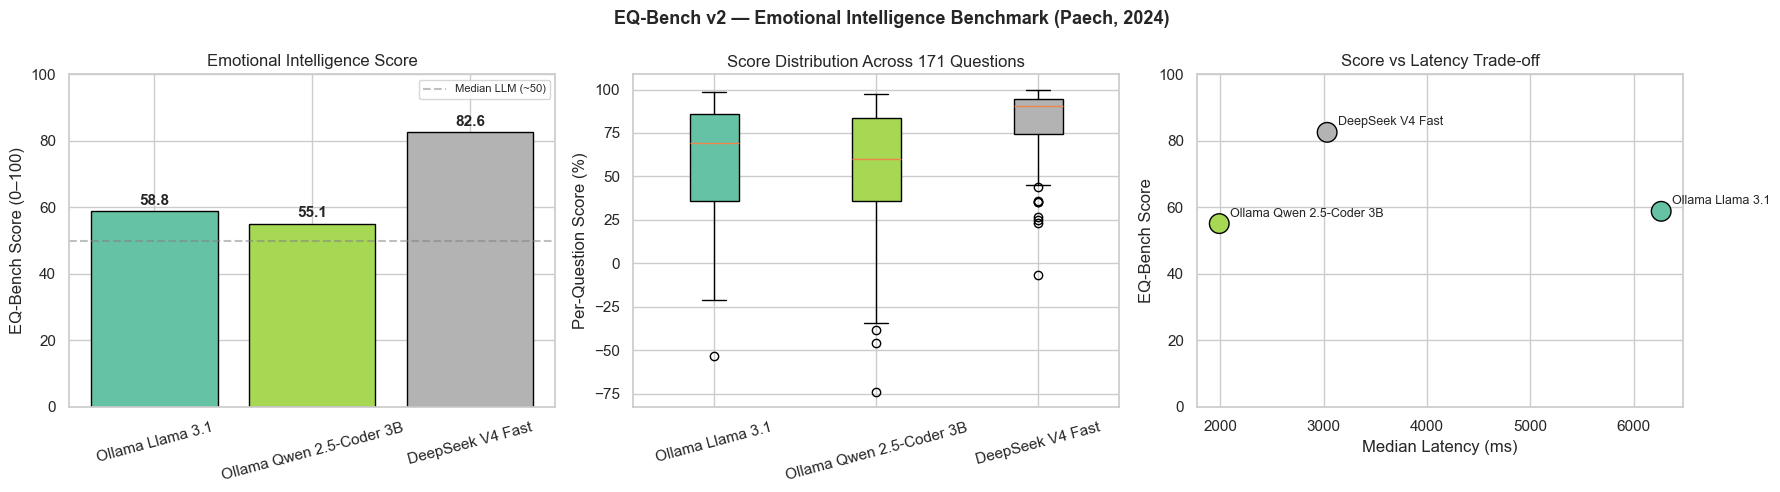

In [24]:
# ── EQ-Bench Results Summary & Visualization ───────────────────────────
import numpy as np

ok_results = {k: v for k, v in EQ_RESULTS.items() if v.get("status") == "ok"}
blocked = {k: v for k, v in EQ_RESULTS.items() if v.get("status") != "ok"}

if ok_results:
    # Summary table
    summary_rows = []
    for pname, r in ok_results.items():
        summary_rows.append({
            "Provider": r["label"],
            "EQ-Bench Score": r["eq_bench_score"],
            "Questions": r["questions_scored"],
            "Parse Failures": r["parse_failures"],
            "Median Latency (ms)": r["median_latency_ms"],
        })
    eq_summary = pd.DataFrame(summary_rows).set_index("Provider")
    print("=" * 60)
    print("EQ-Bench v2 Results (0 = random, 100 = perfect)")
    print("=" * 60)
    print(eq_summary.to_string())

    # Reference scores from EQ-Bench leaderboard for context
    print("\n--- Leaderboard context (eqbench.com) ---")
    print("  GPT-4o:     ~82    |  Llama-3.1-8B:  ~52")
    print("  Claude 3.5: ~78    |  Qwen-2.5-7B:   ~60")
    print("  Gemini Pro: ~75    |  Mistral-7B:    ~46")

    # Visualization
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("EQ-Bench v2 — Emotional Intelligence Benchmark (Paech, 2024)",
                 fontsize=13, fontweight="bold")

    labels = [r["label"] for r in ok_results.values()]
    scores = [r["eq_bench_score"] for r in ok_results.values()]
    latencies = [r["median_latency_ms"] for r in ok_results.values()]

    # 1. Bar chart — EQ-Bench scores
    colors = plt.cm.Set2(np.linspace(0, 1, len(labels)))
    bars = axes[0].bar(labels, scores, color=colors, edgecolor="black")
    axes[0].set_ylabel("EQ-Bench Score (0–100)")
    axes[0].set_title("Emotional Intelligence Score")
    axes[0].set_ylim(0, 100)
    axes[0].axhline(y=50, color="gray", linestyle="--", alpha=0.5, label="Median LLM (~50)")
    axes[0].legend(fontsize=8)
    for bar, s in zip(bars, scores):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                     f"{s:.1f}", ha="center", va="bottom", fontsize=11, fontweight="bold")
    axes[0].tick_params(axis="x", rotation=15)

    # 2. Box plot — per-question score distribution
    score_data = []
    score_labels = []
    for r in ok_results.values():
        per_q_pct = [s * 10 for s in r["raw_scores"]]
        score_data.append(per_q_pct)
        score_labels.append(r["label"])
    bp = axes[1].boxplot(score_data, labels=score_labels, patch_artist=True)
    for patch, c in zip(bp["boxes"], colors):
        patch.set_facecolor(c)
    axes[1].set_ylabel("Per-Question Score (%)")
    axes[1].set_title("Score Distribution Across 171 Questions")
    axes[1].tick_params(axis="x", rotation=15)

    # 3. Scatter — score vs latency
    axes[2].scatter(latencies, scores, s=200, c=colors[:len(labels)],
                    edgecolors="black", zorder=5)
    for lbl, lat, sc in zip(labels, latencies, scores):
        axes[2].annotate(lbl, (lat, sc), textcoords="offset points",
                         xytext=(8, 5), fontsize=9)
    axes[2].set_xlabel("Median Latency (ms)")
    axes[2].set_ylabel("EQ-Bench Score")
    axes[2].set_title("Score vs Latency Trade-off")
    axes[2].set_ylim(0, 100)

    plt.tight_layout()
    plt.savefig("results_02_eqbench.png", dpi=150, bbox_inches="tight")
    plt.show()

if blocked:
    print("\n--- Inaccessible providers ---")
    for pname, r in blocked.items():
        label = PROVIDERS[pname]["label"]
        print(f"  {label}: {r.get('error', r.get('status', 'unknown'))}")

## Part B — Urban Emotion Test (Domain-Specific, Supplementary)

15 urban agent scenarios scored using:
- **Plutchik's Wheel of Emotions** (1980) — 8 primary emotion dimensions
- **NRC Emotion Lexicon methodology** (Mohammad & Turney, 2013) — lexical coherence analysis

This supplements EQ-Bench with domain-specific evaluation: can the LLM handle
emotion reasoning in the context of urban agent archetypes (tourist, resident, commuter, student)?

In [25]:
import re

# ── Plutchik's Wheel of Emotions (Plutchik, 1980) ──────────────────────
# Maps emotion words to 8 primary dimensions at 3 intensity levels.
# Reference: Plutchik, R. (1980). "Emotion: A Psychoevolutionary Synthesis"

PLUTCHIK_DIMENSIONS = ["joy", "trust", "fear", "surprise", "sadness", "disgust", "anger", "anticipation"]

PLUTCHIK_MAP = {
    # Joy family (ecstasy → joy → serenity)
    "joy": "joy", "happiness": "joy", "happy": "joy", "elation": "joy",
    "delight": "joy", "ecstasy": "joy", "serenity": "joy", "contentment": "joy",
    "pleased": "joy", "euphoria": "joy", "cheerful": "joy", "gratitude": "joy",
    "grateful": "joy", "relief": "joy", "amusement": "joy", "pride": "joy",
    "satisfaction": "joy", "bliss": "joy", "glad": "joy", "peace": "joy",
    # Trust family (admiration → trust → acceptance)
    "trust": "trust", "admiration": "trust", "acceptance": "trust",
    "compassion": "trust", "empathy": "trust", "warmth": "trust",
    "appreciation": "trust", "hope": "trust", "faith": "trust",
    "moved": "trust", "touched": "trust", "tender": "trust",
    "respect": "trust", "comfort": "trust", "reassurance": "trust",
    # Fear family (terror → fear → apprehension)
    "fear": "fear", "anxiety": "fear", "anxious": "fear", "terror": "fear",
    "worry": "fear", "worried": "fear", "panic": "fear", "dread": "fear",
    "nervous": "fear", "apprehension": "fear", "stress": "fear",
    "stressed": "fear", "overwhelm": "fear", "overwhelmed": "fear",
    "uneasy": "fear", "insecure": "fear", "tense": "fear",
    # Surprise family (amazement → surprise → distraction)
    "surprise": "surprise", "surprised": "surprise", "amazement": "surprise",
    "wonder": "surprise", "astonishment": "surprise", "awe": "surprise",
    "disbelief": "surprise", "fascination": "surprise", "shock": "surprise",
    "startled": "surprise", "unexpected": "surprise", "enchantment": "surprise",
    # Sadness family (grief → sadness → pensiveness)
    "sadness": "sadness", "sad": "sadness", "grief": "sadness",
    "melancholy": "sadness", "sorrow": "sadness", "despair": "sadness",
    "loneliness": "sadness", "lonely": "sadness", "isolation": "sadness",
    "homesick": "sadness", "loss": "sadness", "disappointment": "sadness",
    "disappointed": "sadness", "longing": "sadness", "wistful": "sadness",
    "pensiveness": "sadness", "nostalgia": "sadness", "nostalgic": "sadness",
    "bittersweet": "sadness", "sentimental": "sadness", "mournful": "sadness",
    "heartbroken": "sadness", "regret": "sadness",
    # Disgust family (loathing → disgust → boredom)
    "disgust": "disgust", "loathing": "disgust", "contempt": "disgust",
    "boredom": "disgust", "revulsion": "disgust", "distaste": "disgust",
    "aversion": "disgust", "repulsion": "disgust",
    # Anger family (rage → anger → annoyance)
    "anger": "anger", "angry": "anger", "rage": "anger",
    "frustration": "anger", "frustrated": "anger", "irritation": "anger",
    "irritated": "anger", "annoyance": "anger", "annoyed": "anger",
    "resentment": "anger", "impatience": "anger", "impatient": "anger",
    "helplessness": "anger", "indignation": "anger", "outrage": "anger",
    "hostile": "anger", "agitation": "anger",
    # Anticipation family (vigilance → anticipation → interest)
    "anticipation": "anticipation", "interest": "anticipation",
    "curiosity": "anticipation", "curious": "anticipation",
    "excitement": "anticipation", "excited": "anticipation",
    "eager": "anticipation", "vigilance": "anticipation",
    "expectation": "anticipation", "enthusiasm": "anticipation",
    "optimism": "anticipation", "hopeful": "anticipation",
}

# Composite emotions = combinations of two primary dimensions (Plutchik, 1980)
PLUTCHIK_COMPOSITES = {
    "nostalgia": ("sadness", "anticipation"),
    "bittersweet": ("sadness", "joy"),
    "love": ("joy", "trust"),
    "awe": ("surprise", "fear"),
    "envy": ("sadness", "anger"),
    "optimism": ("anticipation", "joy"),
    "remorse": ("sadness", "disgust"),
    "contempt": ("disgust", "anger"),
    "submission": ("trust", "fear"),
    "desperation": ("fear", "sadness"),
    "aggressiveness": ("anger", "anticipation"),
    "guilt": ("joy", "fear"),
    "sentimentality": ("trust", "sadness"),
}


# ── NRC-style lexical emotion analysis ──────────────────────────────────
# Adapted from the NRC Emotion Lexicon methodology (Mohammad & Turney, 2013).
# "Crowdsourcing a Word-Emotion Association Lexicon", Computational Intelligence.
# We use curated word lists per Plutchik dimension for text-level scoring.

NRC_EMOTION_WORDS = {
    "joy":          {"happy", "joy", "love", "beautiful", "wonderful", "good", "smile",
                     "laugh", "delight", "pleasure", "enjoy", "celebration", "warm",
                     "bright", "cheerful", "glad", "content", "satisfied", "bliss",
                     "gratitude", "relief", "proud", "pride", "peace", "serene"},
    "trust":        {"trust", "faith", "honest", "kind", "help", "care", "support",
                     "friend", "safe", "gentle", "compassion", "empathy", "respect",
                     "loyal", "reliable", "admire", "comfort", "protect", "hope",
                     "warmth", "reassure", "moved", "touched"},
    "fear":         {"fear", "afraid", "scared", "worry", "anxiety", "nervous", "panic",
                     "terror", "dread", "threat", "danger", "alarm", "stress",
                     "overwhelm", "tense", "uneasy", "insecure", "desperate",
                     "apprehension", "horror", "fright"},
    "surprise":     {"surprise", "unexpected", "sudden", "shock", "amazed", "wonder",
                     "astonish", "startle", "discover", "remarkable", "incredible",
                     "unbelievable", "wow", "fascinate", "awe", "revelation"},
    "sadness":      {"sad", "cry", "tear", "grief", "loss", "lonely", "miss",
                     "sorrow", "melancholy", "despair", "mourn", "heartbreak",
                     "disappoint", "regret", "nostalgia", "wistful", "longing",
                     "bittersweet", "gloomy", "desolate", "passed", "gone"},
    "disgust":      {"disgust", "hate", "ugly", "terrible", "horrible", "nasty",
                     "revolting", "repulsive", "gross", "vile", "loathe", "contempt",
                     "sick", "nauseating", "abhor", "distaste"},
    "anger":        {"anger", "angry", "furious", "rage", "frustrat", "annoy", "irritat",
                     "hate", "hostile", "resent", "impatient", "outrage", "mad",
                     "agitat", "infuriat", "bitter", "helpless", "stuck"},
    "anticipation": {"expect", "hope", "anticipat", "plan", "future", "eager",
                     "excit", "curious", "interest", "looking forward", "wait",
                     "optimis", "enthusia", "ready", "prepare", "prospect"},
}


def nrc_analyze_text(text: str) -> dict[str, float]:
    """Score text across 8 Plutchik dimensions using NRC-style word matching.
    Returns normalized distribution (sums to 1.0 if any matches found)."""
    text_lower = text.lower()
    words = re.findall(r"[a-z]+", text_lower)
    scores = {dim: 0 for dim in PLUTCHIK_DIMENSIONS}

    for dim, lexicon in NRC_EMOTION_WORDS.items():
        for lex_word in lexicon:
            # Stem-aware matching: check if any word starts with the lexicon entry
            for w in words:
                if w.startswith(lex_word) or lex_word.startswith(w):
                    scores[dim] += 1
            # Also check for multi-word phrases
            if " " in lex_word and lex_word in text_lower:
                scores[dim] += 1

    total = sum(scores.values())
    if total > 0:
        scores = {k: v / total for k, v in scores.items()}
    return scores


def map_to_plutchik(emotion_word: str) -> str | None:
    """Map an emotion word to its Plutchik primary dimension."""
    word = emotion_word.lower().strip()
    if word in PLUTCHIK_MAP:
        return PLUTCHIK_MAP[word]
    # Fuzzy: check if any key is a substring
    for key, dim in PLUTCHIK_MAP.items():
        if key in word or word in key:
            return dim
    return None


# ── Scoring framework ──────────────────────────────────────────────────

def score_response(parsed: dict, scenario: dict) -> dict:
    """Score a parsed LLM response using Plutchik + NRC methodology.

    Metrics (Plutchik, 1980; Mohammad & Turney, 2013):
      1. plutchik_match     — primary emotion maps to correct Plutchik dimension
      2. composite_detected — secondary emotion maps to expected secondary dimension
      3. intensity_calibrated — intensity within expected range for the scenario
      4. nrc_coherence      — NRC lexical analysis of reasoning aligns with expected dimensions
      5. behavior_aligned   — behavioral response matches expected actions
    """
    primary = (parsed.get("primary_emotion") or "").lower().strip()
    secondary = (parsed.get("secondary_emotion") or "").lower().strip()
    behavior = (parsed.get("behavioral_response") or "").lower()
    reasoning = (parsed.get("reasoning") or "").lower()

    # 1. Plutchik dimension match
    predicted_dim = map_to_plutchik(primary)
    plutchik_match = predicted_dim == scenario["plutchik_primary"]

    # 2. Composite emotion detection
    predicted_secondary_dim = map_to_plutchik(secondary)
    composite_detected = predicted_secondary_dim == scenario.get("plutchik_secondary")

    # 3. Intensity calibration
    intensity = parsed.get("intensity", -1)
    expected_range = scenario.get("expected_intensity", [0, 1])
    intensity_calibrated = (
        isinstance(intensity, (int, float))
        and expected_range[0] <= intensity <= expected_range[1]
    )

    # 4. NRC lexical coherence — analyze the full reasoning text
    full_text = f"{primary} {secondary} {behavior} {reasoning}"
    nrc_scores = nrc_analyze_text(full_text)
    expected_primary = scenario["plutchik_primary"]
    expected_secondary = scenario.get("plutchik_secondary")
    # Coherence = expected dimension(s) are in the top-3 scoring dimensions
    sorted_dims = sorted(nrc_scores, key=nrc_scores.get, reverse=True)
    top_3 = sorted_dims[:3]
    nrc_coherence = expected_primary in top_3
    if expected_secondary:
        nrc_coherence = nrc_coherence and expected_secondary in top_3[:4]

    # 5. Behavioral alignment
    expected_behaviors = [b.lower() for b in scenario["expected_behavior"]]
    behavior_aligned = any(
        exp.replace("_", " ") in behavior or exp.replace("_", " ") in reasoning
        for exp in expected_behaviors
    )

    return {
        "plutchik_match": plutchik_match,
        "composite_detected": composite_detected,
        "intensity_calibrated": intensity_calibrated,
        "nrc_coherence": nrc_coherence,
        "behavior_aligned": behavior_aligned,
        "predicted_dimension": predicted_dim or "unmapped",
        "expected_dimension": expected_primary,
        "primary_emotion": primary,
        "secondary_emotion": secondary,
        "nrc_top_dim": sorted_dims[0] if sorted_dims else "",
    }


# ── Prompt and benchmark function ──────────────────────────────────────

EMOTION_PROMPT = """You are simulating a {archetype} agent in an urban environment (Barcelona, Eixample district).

**Current state:**
- Mood: {mood}
- Needs: hunger={hunger:.1f}, energy={energy:.1f}, social={social:.1f}

**Situation:**
{situation}

Based on this scenario, analyze the agent's emotional response. Consider the archetype's personality, their current needs, and how the situation would realistically affect a human in this role.

Reply with JSON only:
{{
  "primary_emotion": "<single most dominant emotion word>",
  "secondary_emotion": "<a subtler or underlying emotion>",
  "intensity": <0.0 to 1.0>,
  "behavioral_response": "<what the agent would do next, 1 sentence>",
  "reasoning": "<why this emotion arises given the archetype and situation, 1-2 sentences>"
}}"""


def build_emotion_prompt(scenario):
    return EMOTION_PROMPT.format(
        archetype=scenario["archetype"],
        mood=scenario["current_mood"],
        hunger=scenario["needs"]["hunger"],
        energy=scenario["needs"]["energy"],
        social=scenario["needs"]["social"],
        situation=scenario["situation"],
    )


async def bench_emotion(name, config, scenarios, runs_per_scenario=2):
    """Benchmark one provider on all emotion scenarios with Plutchik + NRC scoring."""
    client = AsyncOpenAI(api_key=config["api_key"], base_url=config["base_url"])

    try:
        await client.chat.completions.create(
            model=config["model"],
            messages=[{"role": "user", "content": "Reply: hello"}],
            max_tokens=10, timeout=15,
        )
    except Exception as e:
        reason = str(e)
        if any(k in reason.lower() for k in ["connect", "refused"]):
            reason = "service unreachable (not running)"
        elif any(k in reason.lower() for k in ["api_key", "auth", "unauthorized"]):
            reason = "authentication failed (check API key)"
        print(f"  [{name}] ACCESS NOT POSSIBLE — {reason}")
        return [{"provider": name, "status": "access_not_possible", "error": reason}]

    results = []
    for scenario in scenarios:
        prompt = build_emotion_prompt(scenario)
        for run in range(runs_per_scenario):
            t0 = time.perf_counter()
            try:
                resp = await client.chat.completions.create(
                    model=config["model"],
                    messages=[{"role": "user", "content": prompt}],
                    max_tokens=300, temperature=0.7,
                )
                elapsed = (time.perf_counter() - t0) * 1000
                content = resp.choices[0].message.content or ""

                json_ok = False
                parsed = {}
                try:
                    parsed = json.loads(content)
                    json_ok = True
                except json.JSONDecodeError:
                    match = re.search(r"\{[^{}]*\}", content, re.DOTALL)
                    if match:
                        try:
                            parsed = json.loads(match.group(0))
                            json_ok = True
                        except json.JSONDecodeError:
                            pass

                scores = score_response(parsed, scenario) if json_ok else {
                    "plutchik_match": False, "composite_detected": False,
                    "intensity_calibrated": False, "nrc_coherence": False,
                    "behavior_aligned": False, "predicted_dimension": "parse_error",
                    "expected_dimension": scenario["plutchik_primary"],
                    "primary_emotion": "", "secondary_emotion": "", "nrc_top_dim": "",
                }

                in_tok = resp.usage.prompt_tokens if resp.usage else 0
                out_tok = resp.usage.completion_tokens if resp.usage else 0

                results.append({
                    "provider": name, "status": "ok",
                    "scenario_id": scenario["id"],
                    "category": scenario["category"],
                    "archetype": scenario["archetype"],
                    "latency_ms": elapsed, "json_ok": json_ok,
                    "in_tokens": in_tok, "out_tokens": out_tok,
                    **scores,
                })
            except Exception as e:
                results.append({
                    "provider": name, "status": "error",
                    "scenario_id": scenario["id"],
                    "category": scenario["category"],
                    "archetype": scenario["archetype"],
                    "latency_ms": None, "json_ok": False, "error": str(e),
                    "plutchik_match": False, "composite_detected": False,
                    "intensity_calibrated": False, "nrc_coherence": False,
                    "behavior_aligned": False, "predicted_dimension": "error",
                    "expected_dimension": scenario["plutchik_primary"],
                    "primary_emotion": "", "secondary_emotion": "", "nrc_top_dim": "",
                })
    return results

print(f"Scoring framework: Plutchik (1980) 8-dimension model + NRC lexical analysis (Mohammad & Turney, 2013)")
print(f"Dimensions: {', '.join(PLUTCHIK_DIMENSIONS)}")
print(f"Emotion vocabulary: {len(PLUTCHIK_MAP)} mapped terms, {len(PLUTCHIK_COMPOSITES)} composite emotions")

Scoring framework: Plutchik (1980) 8-dimension model + NRC lexical analysis (Mohammad & Turney, 2013)
Dimensions: joy, trust, fear, surprise, sadness, disgust, anger, anticipation
Emotion vocabulary: 124 mapped terms, 13 composite emotions


In [26]:
RESULTS = {}
print("Results store initialised. Now run one or more provider cells below.")

Results store initialised. Now run one or more provider cells below.


### Provider 1 — Ollama Llama 3.1 (local)

In [27]:
_name = "llama3.1"
_config = PROVIDERS[_name]

print(f"Benchmarking {_config['label']} on {len(SCENARIOS)} emotion scenarios ...")
_rows = await bench_emotion(_name, _config, SCENARIOS)

RESULTS[_name] = _rows

_ok = [r for r in _rows if r["status"] == "ok"]
if _ok:
    _df = pd.DataFrame(_ok)
    print(f"  {len(_ok)} samples collected")
    print(f"  Plutchik match:        {_df['plutchik_match'].mean()*100:.1f}%")
    print(f"  Composite detection:   {_df['composite_detected'].mean()*100:.1f}%")
    print(f"  Intensity calibrated:  {_df['intensity_calibrated'].mean()*100:.1f}%")
    print(f"  NRC coherence:         {_df['nrc_coherence'].mean()*100:.1f}%")
    print(f"  Behavior alignment:    {_df['behavior_aligned'].mean()*100:.1f}%")
    print(f"  JSON compliance:       {_df['json_ok'].mean()*100:.1f}%")
    print(f"  Median latency:        {_df['latency_ms'].median():.0f} ms")
else:
    _err = _rows[0].get("error", "unknown") if _rows else "no response"
    print(f"  ACCESS NOT POSSIBLE — {_err}")

Benchmarking Ollama Llama 3.1 on 15 emotion scenarios ...
  30 samples collected
  Plutchik match:        63.3%
  Composite detection:   13.3%
  Intensity calibrated:  90.0%
  NRC coherence:         26.7%
  Behavior alignment:    30.0%
  JSON compliance:       100.0%
  Median latency:        2911 ms


### Provider 2 — Ollama Qwen 2.5-Coder (local)

In [28]:
_name = "qwen2.5-coder"
_config = PROVIDERS[_name]

print(f"Benchmarking {_config['label']} on {len(SCENARIOS)} emotion scenarios ...")
_rows = await bench_emotion(_name, _config, SCENARIOS)

RESULTS[_name] = _rows

_ok = [r for r in _rows if r["status"] == "ok"]
if _ok:
    _df = pd.DataFrame(_ok)
    print(f"  {len(_ok)} samples collected")
    print(f"  Plutchik match:        {_df['plutchik_match'].mean()*100:.1f}%")
    print(f"  Composite detection:   {_df['composite_detected'].mean()*100:.1f}%")
    print(f"  Intensity calibrated:  {_df['intensity_calibrated'].mean()*100:.1f}%")
    print(f"  NRC coherence:         {_df['nrc_coherence'].mean()*100:.1f}%")
    print(f"  Behavior alignment:    {_df['behavior_aligned'].mean()*100:.1f}%")
    print(f"  JSON compliance:       {_df['json_ok'].mean()*100:.1f}%")
    print(f"  Median latency:        {_df['latency_ms'].median():.0f} ms")
else:
    _err = _rows[0].get("error", "unknown") if _rows else "no response"
    print(f"  ACCESS NOT POSSIBLE — {_err}")

Benchmarking Ollama Qwen 2.5-Coder 3B on 15 emotion scenarios ...
  30 samples collected
  Plutchik match:        50.0%
  Composite detection:   20.0%
  Intensity calibrated:  80.0%
  NRC coherence:         13.3%
  Behavior alignment:    30.0%
  JSON compliance:       100.0%
  Median latency:        1597 ms


### Provider 3 — DeepSeek V4 Fast (cloud API)

In [29]:
_name = "deepseek"
_config = PROVIDERS[_name]

print(f"Benchmarking {_config['label']} on {len(SCENARIOS)} emotion scenarios ...")
_rows = await bench_emotion(_name, _config, SCENARIOS)

RESULTS[_name] = _rows

_ok = [r for r in _rows if r["status"] == "ok"]
if _ok:
    _df = pd.DataFrame(_ok)
    print(f"  {len(_ok)} samples collected")
    print(f"  Plutchik match:        {_df['plutchik_match'].mean()*100:.1f}%")
    print(f"  Composite detection:   {_df['composite_detected'].mean()*100:.1f}%")
    print(f"  Intensity calibrated:  {_df['intensity_calibrated'].mean()*100:.1f}%")
    print(f"  NRC coherence:         {_df['nrc_coherence'].mean()*100:.1f}%")
    print(f"  Behavior alignment:    {_df['behavior_aligned'].mean()*100:.1f}%")
    print(f"  JSON compliance:       {_df['json_ok'].mean()*100:.1f}%")
    print(f"  Median latency:        {_df['latency_ms'].median():.0f} ms")
else:
    _err = _rows[0].get("error", "unknown") if _rows else "no response"
    print(f"  ACCESS NOT POSSIBLE — {_err}")

Benchmarking DeepSeek V4 Fast on 15 emotion scenarios ...
  30 samples collected
  Plutchik match:        76.7%
  Composite detection:   33.3%
  Intensity calibrated:  90.0%
  NRC coherence:         20.0%
  Behavior alignment:    40.0%
  JSON compliance:       100.0%
  Median latency:        2271 ms


### Summary & Export  *(run after all provider cells)*

In [30]:
if not RESULTS:
    print("No provider results yet — run at least one provider cell above.")
else:
    all_rows = [r for rows in RESULTS.values() for r in rows]
    df = pd.DataFrame(all_rows)
    df.to_csv("results_02_emotion_raw.csv", index=False)

    accessible = df[df["status"] == "ok"].copy()
    blocked = df[df["status"] == "access_not_possible"]["provider"].unique()

    label_map = {k: v["label"] for k, v in PROVIDERS.items()}
    accessible["label"] = accessible["provider"].map(label_map)

    if not accessible.empty:
        summary = (
            accessible
            .groupby("label")
            .agg(
                samples           =("latency_ms", "count"),
                median_lat_ms     =("latency_ms", "median"),
                plutchik_pct      =("plutchik_match", "mean"),
                composite_pct     =("composite_detected", "mean"),
                intensity_pct     =("intensity_calibrated", "mean"),
                nrc_coherence_pct =("nrc_coherence", "mean"),
                behavior_pct      =("behavior_aligned", "mean"),
                json_ok_pct       =("json_ok", "mean"),
            )
            .assign(
                plutchik_pct      =lambda x: (x.plutchik_pct * 100).round(1),
                composite_pct     =lambda x: (x.composite_pct * 100).round(1),
                intensity_pct     =lambda x: (x.intensity_pct * 100).round(1),
                nrc_coherence_pct =lambda x: (x.nrc_coherence_pct * 100).round(1),
                behavior_pct      =lambda x: (x.behavior_pct * 100).round(1),
                json_ok_pct       =lambda x: (x.json_ok_pct * 100).round(1),
                median_lat_ms     =lambda x: x.median_lat_ms.round(0),
            )
        )
        print("=== Human Emotion Test — Plutchik + NRC Scoring ===")
        print(summary.to_string())

        print("\n=== Plutchik Dimension Accuracy by Scenario Category ===")
        cat_summary = (
            accessible
            .groupby(["label", "category"])["plutchik_match"]
            .mean()
            .unstack(fill_value=0)
            .applymap(lambda x: f"{x*100:.0f}%")
        )
        print(cat_summary.to_string())

        print("\n=== Confusion: Predicted vs Expected Plutchik Dimension ===")
        confusion = pd.crosstab(
            accessible["predicted_dimension"],
            accessible["expected_dimension"],
            margins=True,
        )
        print(confusion.to_string())

    if len(blocked):
        print("\n=== ACCESS NOT POSSIBLE ===")
        for p in blocked:
            err = df[df["provider"] == p]["error"].iloc[0]
            label = PROVIDERS.get(p, {}).get("label", p)
            print(f"  {label}: {err}")

    if accessible.empty:
        print("No providers returned results.")

=== Human Emotion Test — Plutchik + NRC Scoring ===
                          samples  median_lat_ms  plutchik_pct  composite_pct  intensity_pct  nrc_coherence_pct  behavior_pct  json_ok_pct
label                                                                                                                                     
DeepSeek V4 Fast               30         2271.0          76.7           33.3           90.0               20.0          40.0        100.0
Ollama Llama 3.1               30         2911.0          63.3           13.3           90.0               26.7          30.0        100.0
Ollama Qwen 2.5-Coder 3B       30         1597.0          50.0           20.0           80.0               13.3          30.0        100.0

=== Plutchik Dimension Accuracy by Scenario Category ===
category                 empathy escalation negative_shift nuanced positive_shift
label                                                                            
DeepSeek V4 Fast             50

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_58252\2612047956.py:47: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  .applymap(lambda x: f"{x*100:.0f}%")


### Visualisation

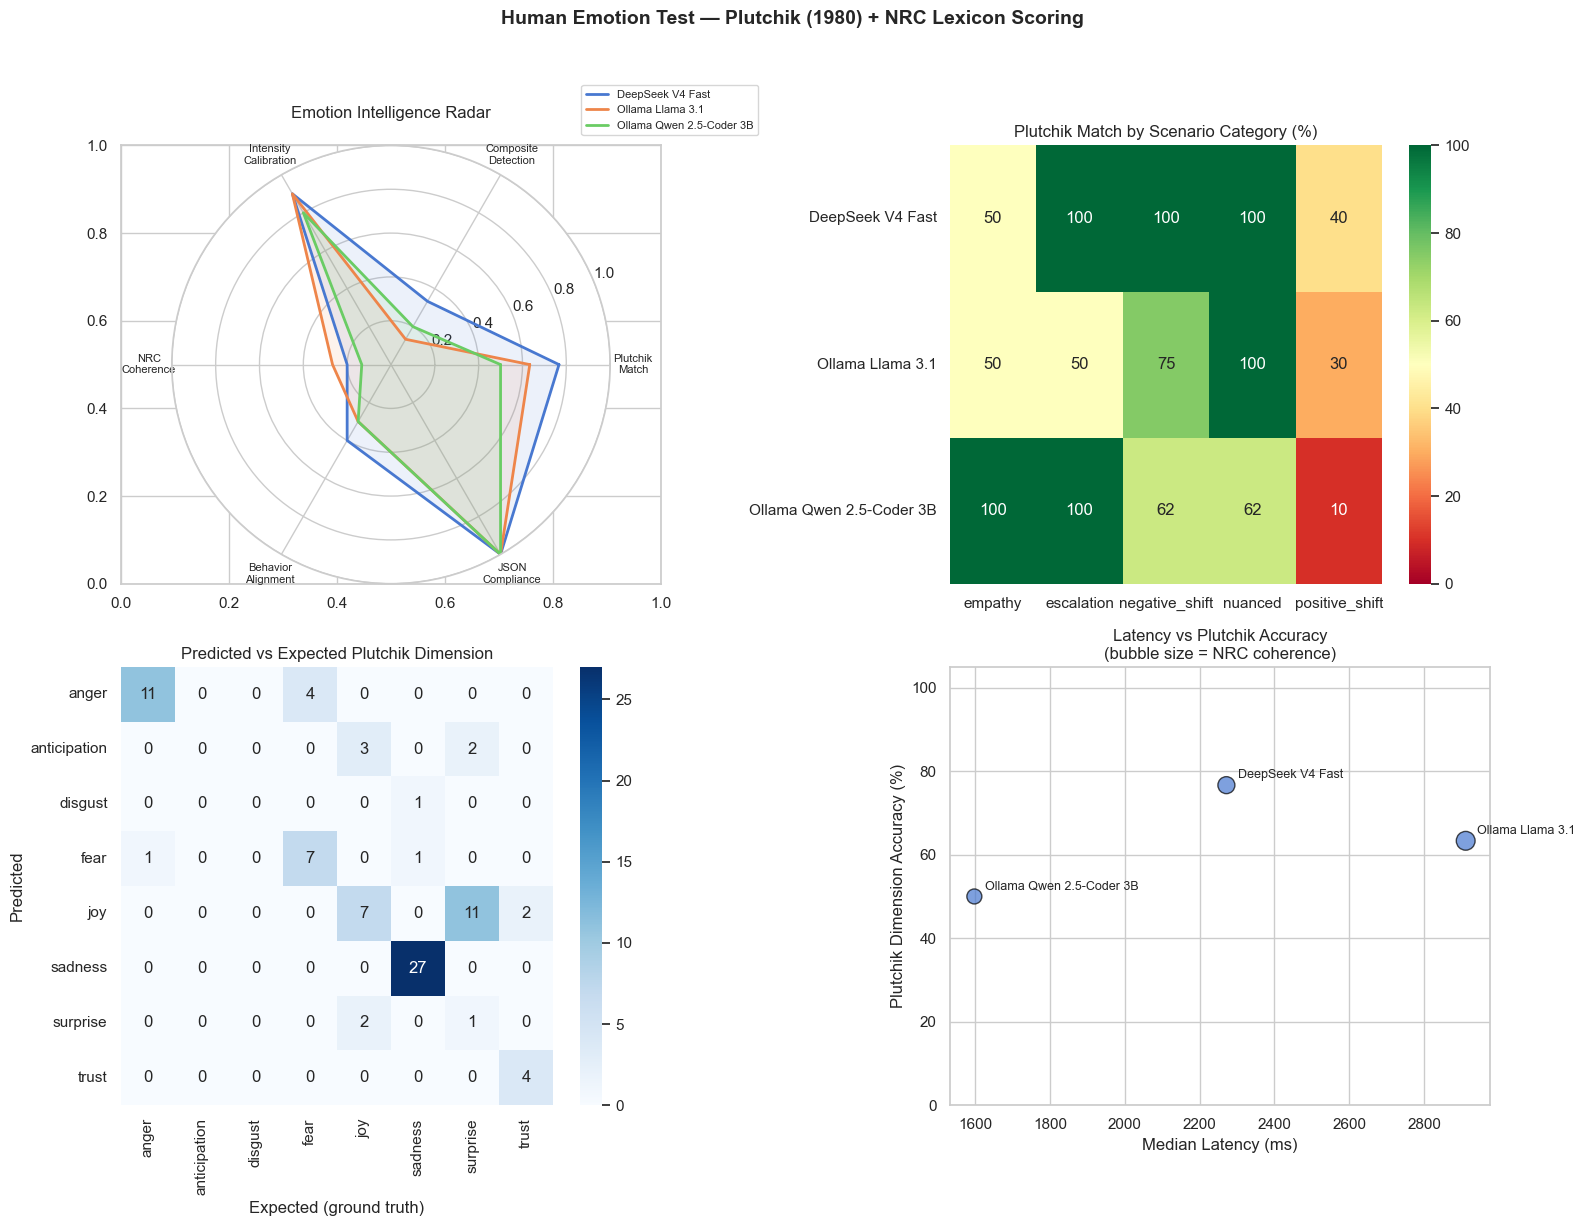

In [31]:
_all_rows  = [r for rows in RESULTS.values() for r in rows]
df         = pd.DataFrame(_all_rows)
accessible = df[df["status"] == "ok"].copy()
blocked    = list(df[df["status"] == "access_not_possible"]["provider"].unique())

label_map = {k: v["label"] for k, v in PROVIDERS.items()}
accessible["label"] = accessible["provider"].map(label_map)

if accessible.empty:
    print("Nothing to plot — no accessible providers.")
else:
    import numpy as np

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle("Human Emotion Test — Plutchik (1980) + NRC Lexicon Scoring",
                 fontsize=14, fontweight="bold", y=1.02)

    # 1. Radar chart — Plutchik + NRC metrics per provider
    metrics = ["plutchik_match", "composite_detected", "intensity_calibrated",
               "nrc_coherence", "behavior_aligned", "json_ok"]
    metric_labels = ["Plutchik\nMatch", "Composite\nDetection", "Intensity\nCalibration",
                     "NRC\nCoherence", "Behavior\nAlignment", "JSON\nCompliance"]
    metric_data = accessible.groupby("label")[metrics].mean()

    n = len(metrics)
    angles = [i / n * 2 * np.pi for i in range(n)] + [0]
    ax_radar = plt.subplot(2, 2, 1, polar=True)
    for label, row in metric_data.iterrows():
        vals = row.tolist() + [row.iloc[0]]
        ax_radar.plot(angles, vals, label=label, linewidth=2)
        ax_radar.fill(angles, vals, alpha=0.1)
    ax_radar.set_xticks(angles[:-1])
    ax_radar.set_xticklabels(metric_labels, size=8)
    ax_radar.set_ylim(0, 1)
    ax_radar.set_title("Emotion Intelligence Radar", pad=20)
    ax_radar.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=8)

    # 2. Heatmap — Plutchik accuracy by category × provider
    cat_acc = (
        accessible
        .groupby(["label", "category"])["plutchik_match"]
        .mean()
        .unstack(fill_value=0) * 100
    )
    sns.heatmap(cat_acc, annot=True, fmt=".0f", cmap="RdYlGn",
                vmin=0, vmax=100, ax=axes[0,1])
    axes[0,1].set_title("Plutchik Match by Scenario Category (%)")
    axes[0,1].set_ylabel("")
    axes[0,1].set_xlabel("")

    # 3. Confusion matrix — predicted vs expected Plutchik dimension (all providers)
    pred_vs_exp = accessible[accessible["predicted_dimension"] != "unmapped"]
    if not pred_vs_exp.empty:
        all_dims = sorted(set(pred_vs_exp["predicted_dimension"]) |
                          set(pred_vs_exp["expected_dimension"]))
        confusion = pd.crosstab(
            pred_vs_exp["predicted_dimension"],
            pred_vs_exp["expected_dimension"],
        ).reindex(index=all_dims, columns=all_dims, fill_value=0)
        sns.heatmap(confusion, annot=True, fmt="d", cmap="Blues", ax=axes[1,0])
        axes[1,0].set_title("Predicted vs Expected Plutchik Dimension")
        axes[1,0].set_ylabel("Predicted")
        axes[1,0].set_xlabel("Expected (ground truth)")
    else:
        axes[1,0].text(0.5, 0.5, "No valid predictions", ha="center", va="center")
        axes[1,0].set_title("Predicted vs Expected Plutchik Dimension")

    # 4. Scatter — latency vs Plutchik accuracy (bubble = NRC coherence)
    smry = accessible.groupby("label").agg(
        latency_ms=("latency_ms", "median"),
        plutchik_acc=("plutchik_match", "mean"),
        nrc_coh=("nrc_coherence", "mean"),
    ).reset_index()
    axes[1,1].scatter(
        smry["latency_ms"], smry["plutchik_acc"] * 100,
        s=smry["nrc_coh"] * 500 + 50, alpha=0.7, edgecolors="black",
    )
    for _, row in smry.iterrows():
        axes[1,1].annotate(
            row["label"],
            (row["latency_ms"], row["plutchik_acc"] * 100),
            textcoords="offset points", xytext=(8, 5), fontsize=9,
        )
    axes[1,1].set_title("Latency vs Plutchik Accuracy\n(bubble size = NRC coherence)")
    axes[1,1].set_xlabel("Median Latency (ms)")
    axes[1,1].set_ylabel("Plutchik Dimension Accuracy (%)")
    axes[1,1].set_ylim(0, 105)

    if blocked:
        labels = [PROVIDERS.get(p, {}).get("label", p) for p in blocked]
        fig.text(0.5, -0.02,
                 "ACCESS NOT POSSIBLE: " + ", ".join(labels),
                 ha="center", fontsize=10, color="red")

    plt.tight_layout()
    plt.savefig("results_02_emotion_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()

In [32]:
# ── Export results for HTML report ──────────────────────────────────────
import os

os.makedirs('results', exist_ok=True)

# Part A: EQ-Bench
eq_export = {'providers': []}
for pname, r in EQ_RESULTS.items():
    if r.get('status') == 'ok':
        eq_export['providers'].append({
            'label': r['label'],
            'score': r['eq_bench_score'],
            'questions': r['questions_scored'],
            'failures': r['parse_failures'],
            'median_latency_ms': r['median_latency_ms'],
        })
    else:
        eq_export['providers'].append({
            'label': PROVIDERS[pname]['label'],
            'score': None,
            'status': r.get('status'),
            'error': r.get('error', ''),
        })

with open('results/02_eqbench.json', 'w') as f:
    json.dump(eq_export, f, indent=2)

# Part B: Emotion test
emotion_export = {'providers': []}
_all = [r for rows in RESULTS.values() for r in rows]
_df = pd.DataFrame(_all)
_ok = _df[_df['status'] == 'ok']
if not _ok.empty:
    _lmap = {k: v['label'] for k, v in PROVIDERS.items()}
    _ok = _ok.copy()
    _ok['label'] = _ok['provider'].map(_lmap)
    for label, grp in _ok.groupby('label'):
        emotion_export['providers'].append({
            'label': label,
            'plutchik_pct': round(grp['plutchik_match'].mean() * 100, 1),
            'composite_pct': round(grp['composite_detected'].mean() * 100, 1),
            'intensity_pct': round(grp['intensity_calibrated'].mean() * 100, 1),
            'nrc_coherence_pct': round(grp['nrc_coherence'].mean() * 100, 1),
            'behavior_pct': round(grp['behavior_aligned'].mean() * 100, 1),
            'json_ok_pct': round(grp['json_ok'].mean() * 100, 1),
            'median_latency_ms': round(grp['latency_ms'].median(), 0),
        })

with open('results/02_emotion.json', 'w') as f:
    json.dump(emotion_export, f, indent=2)

print('Exported -> results/02_eqbench.json, results/02_emotion.json')

Exported -> results/02_eqbench.json, results/02_emotion.json
